<a href="https://colab.research.google.com/github/biglalo104/Projects/blob/main/Breast%20Tumor%20Classification(UCI%20Wisconsin%20Diagnostic%20Dataset).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np,matplotlib.pyplot as plt,seaborn as sns,pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split,StratifiedKFold,cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report,ConfusionMatrixDisplay
SEED =42

bc = load_breast_cancer(as_frame=True)
X=bc.data.copy()
y=pd.Series(1-bc.target,index=X.index,name="malignant")#1=maliganant(positive class)

print("Shape:",X.shape)   #(569,30)
print("Missing cells:",X.isna().sum())#0
X=X.drop_duplicates()
y=y.loc[X.index]


#Outlier scan(IQR rule)-Inspectrs,Dont autodelete
q1,q3 = X.quantile(.25),X.quantile(.75);iqr=q3-q1

outlier_mask = (X < q1 - 1.5 * iqr) | (X > q3 + 1.5 * iqr)
outlier_proportions = (outlier_mask.sum() / len(X)).sort_values(ascending=False)
print(outlier_proportions.head(5).round(3))

Shape: (569, 30)
Missing cells: mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
dtype: int64
area error          0.114
radius error        0.067
perimeter error     0.067
worst a

malignant
0    0.627
1    0.373
Name: proportion, dtype: float64


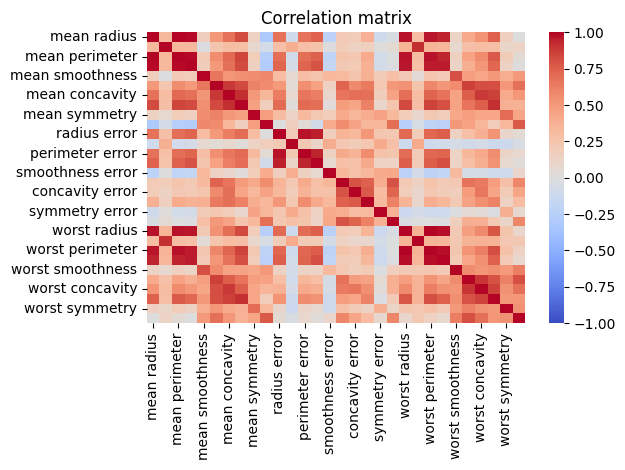

In [3]:
print(y.value_counts(normalize=True).round(3)) #63% benign/37% malignant>mild imbalance
sns.heatmap(X.corr(),cmap="coolwarm",vmin=-1,vmax=1)
plt.title("Correlation matrix");plt.tight_layout();plt.show()

Components for >=90% variance: 7


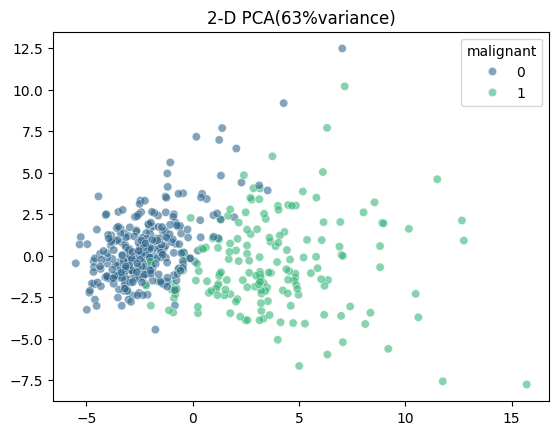

In [4]:
X_tr,X_te,y_tr,y_te=train_test_split(X,y,test_size=0.2,stratify=y,random_state=SEED)

pca = PCA(random_state=SEED).fit(StandardScaler().fit_transform(X_tr))
cum = np.cumsum(pca.explained_variance_ratio_)
print("Components for >=90% variance:",int(np.argmax(cum>=.90)+1)) # typically 7
P = PCA(n_components=2,random_state=SEED)
Z = P.fit_transform(StandardScaler().fit_transform(X_tr))
sns.scatterplot(x=Z[:,0],y=Z[:,1],hue=y_tr,palette="viridis",alpha=0.6)
plt.title(f"2-D PCA({P.explained_variance_ratio_.sum():.0%}variance)");plt.show()

RF(raw) CV Results: {'accuracy': np.float64(0.958), 'roc_auc': np.float64(0.988), 'recall': np.float64(0.935)}
--- RF(raw) Test Set Evaluation ---
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        72
           1       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



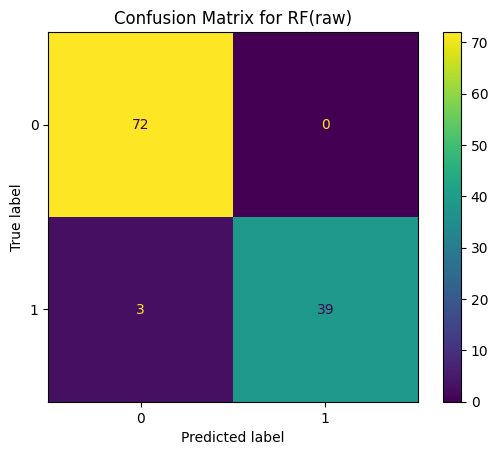

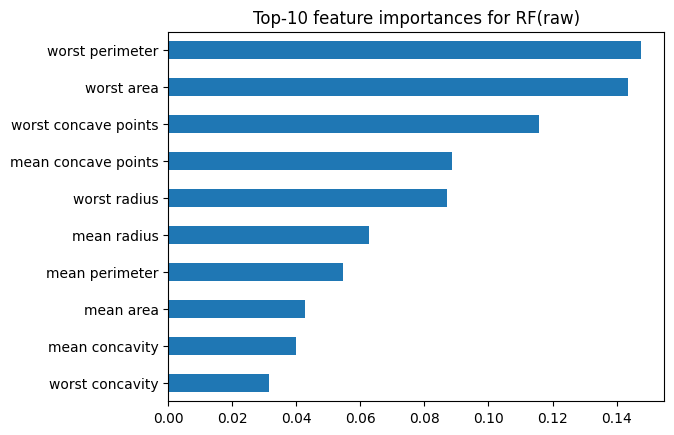

LR(PCA-7) CV Results: {'accuracy': np.float64(0.971), 'roc_auc': np.float64(0.994), 'recall': np.float64(0.953)}
--- LR(PCA-7) Test Set Evaluation ---
              precision    recall  f1-score   support

           0       0.97      0.99      0.98        72
           1       0.98      0.95      0.96        42

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



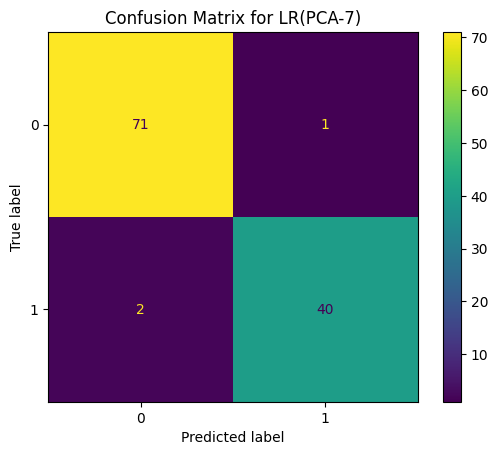

In [7]:
cv= StratifiedKFold(5,shuffle=True,random_state=SEED)
rf = RandomForestClassifier(n_estimators=300,min_samples_leaf=2,random_state=SEED,n_jobs=-1)
lr_pca = Pipeline([("sc",StandardScaler()),("pca",PCA(n_components=7, random_state=SEED)),("lr",LogisticRegression(max_iter=1000, random_state=SEED))])

for name,model in[('RF(raw)',rf),('LR(PCA-7)',lr_pca)]:
  s=cross_validate(model,X_tr,y_tr,cv=cv,scoring=("accuracy","roc_auc","recall"))
  print(f"{name} CV Results:", {k[5:]:round(v.mean(),3)for k,v in s.items()if k.startswith("test_")})

  model.fit(X_tr,y_tr)
  y_pred = model.predict(X_te)

  print(f"--- {name} Test Set Evaluation ---")
  print(classification_report(y_te,y_pred))
  ConfusionMatrixDisplay.from_estimator(model,X_te,y_te);plt.title(f"Confusion Matrix for {name}");plt.show()

  if hasattr(model, 'feature_importances_'):
    pd.Series(model.feature_importances_,index=X.columns).sort_values().tail(10).plot.barh()
    plt.title(f"Top-10 feature importances for {name}");plt.show()
  elif isinstance(model, Pipeline) and hasattr(model.named_steps.get('rf'), 'feature_importances_'):
      # This case handles a pipeline whose final estimator is a RandomForestClassifier
      rf_estimator = model.named_steps['rf']
      pd.Series(rf_estimator.feature_importances_,index=X.columns).sort_values().tail(10).plot.barh()
      plt.title(f"Top-10 feature importances for {name} (from RF in Pipeline)");plt.show()
  # For Logistic Regression, coefficients of PCA components could be inspected,
  # but direct 'feature_importances_' of original features is not straightforward.